# Digital Phenotyping Pipeline for Plant Growth and Yield Prediction

This project simulates a greenhouse phenotyping system where multi-modal sensor data (imaging, environmental, and structural traits) is used to analyse plant growth and predict final yield.

### Objectives
1. Simulate realistic phenotyping data (imaging, environment, stress)
2. Explore relationships between environmental conditions and plant growth
3. Build a machine learning model to predict yield
4. Interpret model predictions using explainable AI (SHAP)

### 1. Synthetic Dataset Description
The synthetic dataset is designed to mimic a real greenhouse phenotyping setup, where plant growth is monitored using a combination of imaging systems, environmental sensors, and physiological instruments. It contains **50 individual plants**, each tracked over a **30-day period**, resulting in **1,500 time-series observations**.
Each plant is treated as an independent experimental unit and is measured longitudinally over time to capture dynamic growth responses under different environmental conditions.

##### Experimental Scale
- Number of plants: 50
- Observation period: 30 days per plant
- Total observations: 1,500 time-series data points

##### a. Imaging-derived features
These variables simulate outputs from multispectral and imaging-based phenotyping systems. Multispectral imaging systems are used to capture plant reflectance in red and near-infrared bands, enabling the computation of vegetation indices such as NDVI. Structural traits such as canopy volume and plant height are derived from 3D point clouds obtained via **LiDAR** or depth imaging systems (e.g., PlantEye).
- **Normalized Difference Vegetation Index (NDVI)** → proxy for plant health and greenness  
  - To bridge image-based sensing and tabular data, we simulate Red and NIR images and compute NDVI at the pixel level. Pixel-level NDVI values are then aggregated to obtain plant-level features.
  - Computed as:
                $NDVI = \frac{NIR - Red}{NIR + Red}$.
  - **NIR**: Near-infrared light reflected by plants  
  - **Red**: Red light absorbed by chlorophyll    
- **Greenness index** → proxy for chlorophyll content  
- **Canopy volume** → 3D structural estimate of biomass (e.g., LiDAR-based measurement)

##### b. Environmental sensors (time-varying)
These variables represent greenhouse environmental conditions influencing plant growth. Greenhouse conditions are continuously monitored using environmental sensors that record temperature, humidity, CO₂ concentration, and light intensity. In addition, systems such as LI-COR can be used to measure gas exchange and photosynthetic activity, providing deeper insight into plant physiological responses.
- **Temperature** → ambient temperature conditions
- **Humidity** → relative air humidity
- **CO₂** → atmospheric carbon dioxide level
- **Light intensity** → continuous light exposure measurement
**LI-COR** instruments measure key environmental and biological parameters focusing on photosynthesis, gas exchange, and light.
##### c. Stress indicators
Water stress is not directly measured but inferred from environmental conditions and physiological measurements, such as transpiration and stomatal conductance. These signals are integrated into a composite stress index.
- **Water stress index** → composite indicator of plant water and environmental stress
Higher values indicate increased physiological stress and reduced growth conditions
##### d. Morphological traits
These variables describe physical plant development. Plant structural traits, including height and leaf area, are extracted from imaging data through segmentation and geometric analysis.
- **Plant height** → vertical growth over time
- **Leaf area** → vegetative expansion and biomass proxy
##### e. Intervention
This variable is used to evaluate treatment effects on plant growth dynamics. Controlled treatments (e.g., fertilizer application) are applied to evaluate their effects on plant growth and to enable causal analysis of environmental and physiological responses.
- **treatment** → categorical variable representing experimental condition
  - Control group
  - Fertilizer treatment

- Load packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

- Load dataset 

In [2]:
df = pd.read_csv("plant_growth_sensor_data.csv")
df

,plant_id,day,height,leaf_area,temperature,light,light_intensity,humidity,co2,ndvi,greenness_index,canopy_volume,water_stress_index,treatment
0,P1,1,5.578180,10.649935,26,low,230.315459,67.615149,405.580826,0.399946,0.651590,51.884027,0.813389,control
1,P1,2,5.633090,11.842791,26,low,187.158618,64.082225,369.522480,0.397814,0.647892,74.321312,0.853956,control
2,P1,3,6.073357,13.450605,26,low,184.536930,52.876259,402.444383,0.409462,0.710624,68.543813,0.990134,control
3,P1,4,6.860038,12.934100,26,low,193.116486,57.331756,399.889443,0.444988,0.667848,89.440660,0.965636,control
4,P1,5,7.000350,17.351831,26,low,226.452831,60.984306,404.372766,0.419825,0.662512,110.359294,0.850818,control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,P50,26,15.563915,37.776022,26,medium,428.294776,56.402638,387.497852,0.611101,1.000928,636.895328,0.631132,control
1496,P50,27,15.915904,33.132433,26,medium,411.761335,67.286858,401.869170,0.601020,1.015735,563.180507,0.609207,control
1497,P50,28,16.030510,36.875072,26,medium,419.616778,69.916868,404.630570,0.590068,1.044447,541.679631,0.585860,control
1498,P50,29,16.477807,32.658050,26,medium,361.861473,63.100025,420.551054,0.651366,1.025684,577.459501,0.656694,control


### 2. Exploratory Data Analysis (EDA)
The exploratory analysis aims to investigate how plant growth dynamics vary across environmental conditions, treatments, and time. We focus on understanding overall growth patterns, distributions of key phenotypic traits, and relationships between environmental and biological variables.
(1) Growth dynamics (plant height for 30 days) across light conditions
(2) Plant height across environmental conditions: correlation
(3) NVDI
(4) water stress

#### 2.1 Growth Dynamics Across Light Conditions

- Since light is a key driver of photosynthesis, we compare plant growth trajectories under different light conditions.

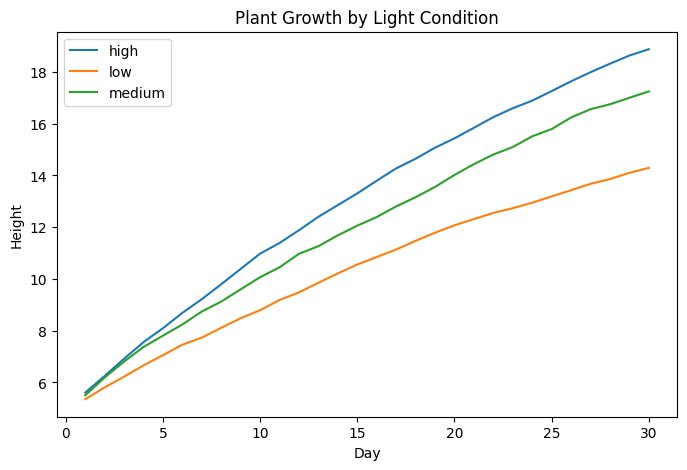

In [3]:
plt.figure(figsize=(8,5))

for key, grp in df.groupby(['light']):
    mean_growth = grp.groupby("day")["height"].mean()
    plt.plot(mean_growth.index, mean_growth.values, label=key)

plt.xlabel("Day")
plt.ylabel("Height")
plt.title("Plant Growth by Light Condition")
plt.legend()
plt.show()

#### 2.2 Environmental Effects on Growth
We investigate how environmental variables influence plant growth using visualization and correlation analysis. 
- light intensity: Light is the main energy source for photosynthesis. It directly controls growth rate and biomass production.
- temperature: shows optimal temperature range for plant growth
- humidity: reflects water balance and transpiration control
- CO₂: CO₂ is a substrate for photosynthesis. So a higher CO₂ means increased carbon fixation and more biomass.


- **Correlation matrix (multi-factor interaction)**

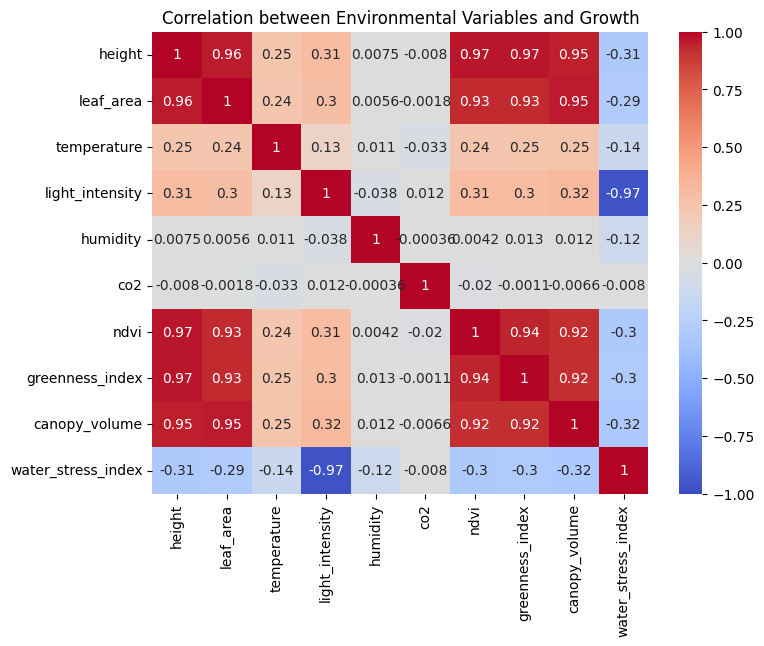

In [4]:
selected_cols = ["height", "leaf_area", "temperature", "light_intensity", "humidity", "co2", "ndvi", "greenness_index", "canopy_volume", "water_stress_index"]

corr = df[selected_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between Environmental Variables and Growth")
plt.show()

The correlation matrix reveals strong relationships between plant growth, physiological traits, and environmental conditions.

Growth-related variables (height, leaf area, canopy volume) are highly correlated, indicating consistent structural development across plants.

NDVI and greenness index show strong positive correlations with growth traits, suggesting that healthier plants exhibit greater biomass accumulation.

Water stress demonstrates a negative correlation with both NDVI and growth variables, confirming its inhibitory effect on plant development.

Environmental variables such as temperature and light intensity show moderate associations, indicating that their effects on growth are mediated through plant physiological responses rather than direct influence.

- **K-means clustering plants by their heights and post-hoc interpretation**

cluster
0    25
1    17
2     8
Name: count, dtype: int64


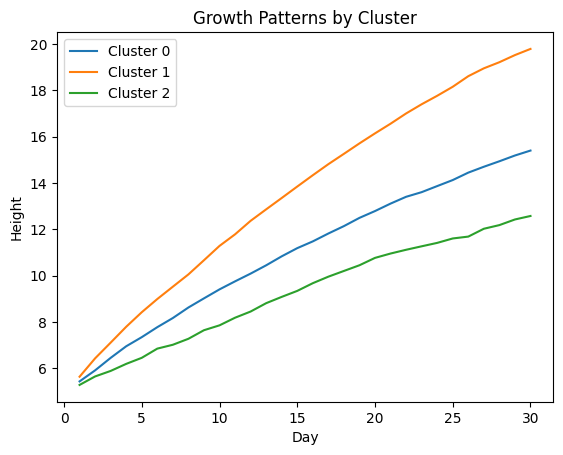

In [5]:
# pivot to wide format
pivot = df.pivot(index="plant_id", columns="day", values="height")

# normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivot)

# cluster
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

pivot["cluster"] = clusters
print(pivot["cluster"].value_counts())
for c in range(3):
    subset = pivot[pivot["cluster"] == c].drop(columns="cluster")
    mean_curve = subset.mean()

    plt.plot(mean_curve.index, mean_curve.values, label=f"Cluster {c}")

plt.legend()
plt.xlabel("Day")
plt.ylabel("Height")
plt.title("Growth Patterns by Cluster")
plt.show()

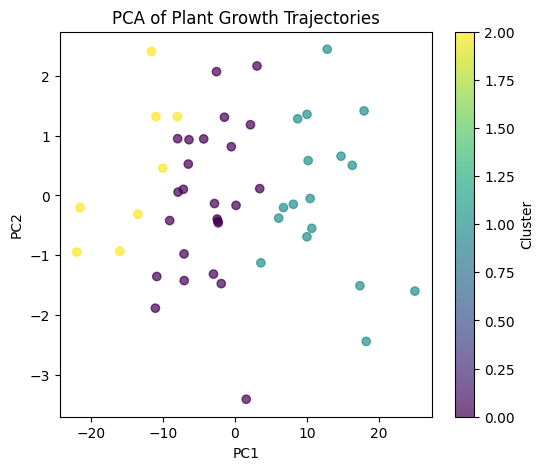

In [6]:
# separate features (remove cluster column)
X = pivot.drop(columns="cluster")

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# create plot
plt.figure(figsize=(6,5))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=pivot["cluster"],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Plant Growth Trajectories")

plt.colorbar(label="Cluster")
plt.show()

In [7]:
df_clustered = df.merge(pivot["cluster"], on="plant_id")

df_clustered.groupby("cluster")[[
    "ndvi",
    "water_stress_index",
    "canopy_volume"
]].mean()

,ndvi,water_stress_index,canopy_volume
cluster,,,
0,0.520368,0.741070,281.044019
1,0.572838,0.585312,442.637470
2,0.485332,0.908804,197.530314


--> Clustering reveals groups of plants with similar growth dynamics, enabling the identification of distinct growth behaviors such as fast-growing, slow-growing, or plateauing plants. Post-hoc analysis indicates that clusters characterized by higher NDVI, lower water stress, and larger canopy volume are associated with increased plant height.

#### 2.3 Imaging-Derived Feature Analysis

We analyze NDVI, greenness index, and canopy volume as indicators of plant health and structure.


- **NVDI**

<Axes: xlabel='ndvi', ylabel='height'>

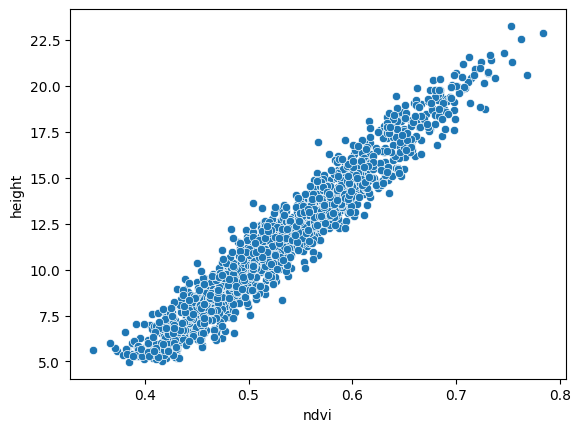

In [8]:
sns.scatterplot(data=df, x="ndvi", y="height")

--> NDVI increases with plant height → proxy for plant health.

- **NVDI (pixel-level)**
--> NDVI is inherently a pixel-level measurement derived from multispectral images. In this section, we simulate images to illustrate how plants with high and low mean NDVI values differ in their spectral characteristics.

In [9]:
class NDVISimulator:
    """
    Simulates Red + NIR plant images and computes NDVI.
    """

    def __init__(self, size=50, plant_strength=1.0, stress_level=0.2):
        """
        size: image size (NxN)
        plant_strength: overall plant health (higher = healthier plant)
        stress_level: environmental stress (higher = worse NDVI)
        """
        self.size = size
        self.plant_strength = plant_strength
        self.stress_level = stress_level

    def generate_synthetic_image(self):
        """
        Create synthetic Red and NIR images.
        """

        base = np.random.normal(0.5, 0.1, (self.size, self.size))

        # simulate "plant region"
        plant_mask = base > 0.55

        # Red reflectance (higher in stressed plants)
        red = np.random.normal(0.3, 0.05, (self.size, self.size))
        red += self.stress_level * 0.2
        red = np.clip(red, 0, 1)

        # NIR reflectance (higher in healthy plants)
        nir = np.random.normal(0.6, 0.05, (self.size, self.size))
        nir += self.plant_strength * plant_mask * 0.3
        nir -= self.stress_level * 0.2
        nir = np.clip(nir, 0, 1)

        return red, nir, plant_mask

    def compute_ndvi(self, red, nir):
        """
        NDVI = (NIR - Red) / (NIR + Red)
        """
        ndvi = (nir - red) / (nir + red + 1e-8)
        return ndvi

    def extract_features(self, ndvi, plant_mask):
        """
        Convert pixel-level NDVI → plant-level traits
        """

        plant_ndvi = ndvi[plant_mask]

        features = {
            "mean_ndvi": np.mean(plant_ndvi),
            "max_ndvi": np.max(plant_ndvi),
            "std_ndvi": np.std(plant_ndvi)
        }

        return features

    def visualize(self, red, nir, ndvi):
        """
        Plot RGB-like interpretation + NDVI map
        """

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("Red Channel")
        plt.imshow(red, cmap="Reds")
        plt.colorbar()

        plt.subplot(1,3,2)
        plt.title("NIR Channel")
        plt.imshow(nir, cmap="Greens")
        plt.colorbar()

        plt.subplot(1,3,3)
        plt.title("NDVI Map")
        plt.imshow(ndvi, cmap="RdYlGn")
        plt.colorbar()

        plt.tight_layout()
        plt.show()

**NDVI Image Explanation**
- **Red channel: shows how much red light the plant reflects.**
- Red light reflectance usually goes up when a plant is stressed because it has less chlorophyll and a weaker leaf structure. Healthy plants absorb more red light, so they reflect less of it.

- **NIR channel (Near-Infrared): shows internal leaf structure.**
- Healthy plants reflect more NIR light because their leaf structure is strong with many air spaces. Stressed plants reflect less.

- **NDVI map: combines Red + NIR into one value.**
- High NDVI (green) = healthy plant
- Low NDVI (yellow/red) = stressed plant

In [10]:
# pick two plant examples with different NDVI values(high and low) to see the differences in the simulated images
df_sorted = df.sort_values("ndvi")
low_ndvi_row = df_sorted.iloc[0]
high_ndvi_row = df_sorted.iloc[-1]

print("Low NDVI:", low_ndvi_row["ndvi"])
print("High NDVI:", high_ndvi_row["ndvi"])

Low NDVI: 0.3499210767135695
High NDVI: 0.7838920635174639


In [11]:
def map_to_sim(row):
    plant_strength = np.clip(row["ndvi"] * 2, 0.5, 2.0)
    stress_level = np.clip(row["water_stress_index"], 0, 1)
    return plant_strength, stress_level

low_ps, low_stress = map_to_sim(low_ndvi_row)
high_ps, high_stress = map_to_sim(high_ndvi_row)

In [12]:
sim_low = NDVISimulator(size=60, plant_strength=low_ps, stress_level=low_stress)
red_low, nir_low, mask_low = sim_low.generate_synthetic_image()
ndvi_low = sim_low.compute_ndvi(red_low, nir_low)

sim_high = NDVISimulator(size=60, plant_strength=high_ps, stress_level=high_stress)
red_high, nir_high, mask_high = sim_high.generate_synthetic_image()
ndvi_high = sim_high.compute_ndvi(red_high, nir_high)

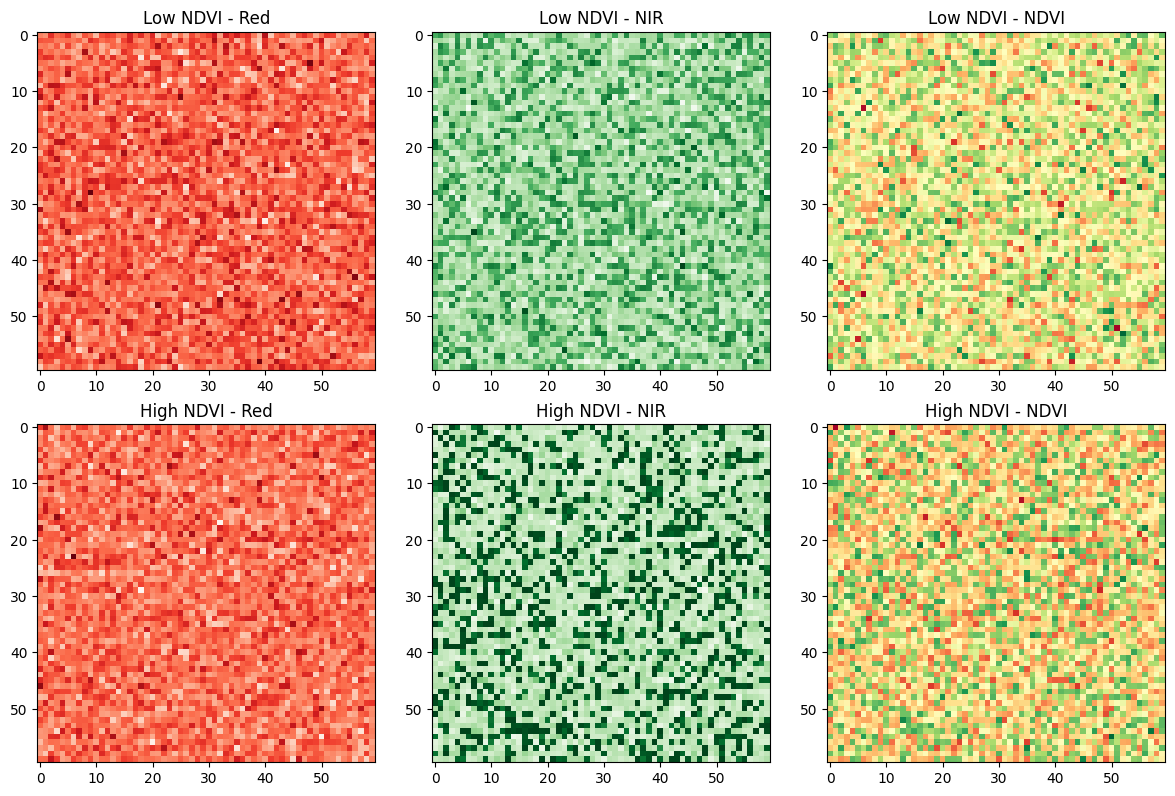

In [13]:
plt.figure(figsize=(12,8))

# LOW NDVI
plt.subplot(2,3,1)
plt.title("Low NDVI - Red")
plt.imshow(red_low, cmap="Reds")

plt.subplot(2,3,2)
plt.title("Low NDVI - NIR")
plt.imshow(nir_low, cmap="Greens")

plt.subplot(2,3,3)
plt.title("Low NDVI - NDVI")
plt.imshow(ndvi_low, cmap="RdYlGn")

# HIGH NDVI
plt.subplot(2,3,4)
plt.title("High NDVI - Red")
plt.imshow(red_high, cmap="Reds")

plt.subplot(2,3,5)
plt.title("High NDVI - NIR")
plt.imshow(nir_high, cmap="Greens")

plt.subplot(2,3,6)
plt.title("High NDVI - NDVI")
plt.imshow(ndvi_high, cmap="RdYlGn")

plt.tight_layout()
plt.show()

- **Treatment Effect on Plant Growth**

/var/folders/ld/vrfv_d594n914y_x2579q59h0000gn/T/ipykernel_91006/4035880124.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x="day", y="height", hue="treatment", ci="sd")


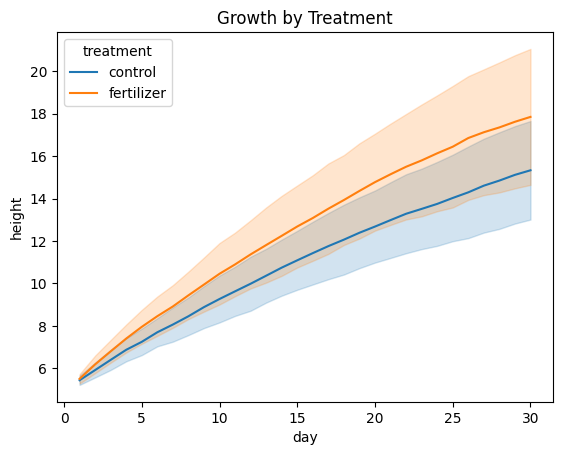

In [14]:
sns.lineplot(data=df, x="day", y="height", hue="treatment", ci="sd")
plt.title("Growth by Treatment")
plt.show()

--> The plot shows how plant growth trajectories differ between treatment groups, allowing us to assess the effect of the intervention over time.

#### 3. Yield prediction model

The exploratory analysis revealed that plant growth is strongly influenced by environmental conditions, particularly light intensity, temperature, humidity, and CO₂ concentration. In addition, imaging-derived traits such as NDVI and canopy volume capture plant physiological status over time.

Based on these findings, we now investigate whether early-stage environmental and phenotypic signals can be used to predict final plant yield. This reflects a key objective in modern plant phenotyping systems: enabling early prediction of crop performance using multi-modal sensor data.

- Create yield target

In [15]:
# use last day as proxy for final yield
final_day = df[df["day"] == df["day"].max()].copy()

final_day["yield"] = (
    0.6 * final_day["height"] +
    0.3 * final_day["canopy_volume"] +
    0.4 * final_day["ndvi"] -
    0.2 * final_day["water_stress_index"] +
    np.random.normal(0, 0.5, len(final_day))
)

In [16]:
early_df = df[df["day"] <= 15]

features = early_df.groupby("plant_id").agg({
    "height": "mean",
    "leaf_area": "mean",
    "ndvi": "mean",
    "canopy_volume": "mean",
    "temperature": "mean",
    "humidity": "mean",
    "co2": "mean",
    "light_intensity": "mean",
    "water_stress_index": "mean"
}).reset_index()

data = features.merge(final_day[["plant_id", "yield"]], on="plant_id")

- **Built a Random Forest model to predict crop yield using environmental variables and treatment conditions.**

R² score: 0.6659516936683323
MAE: 33.16569644497644


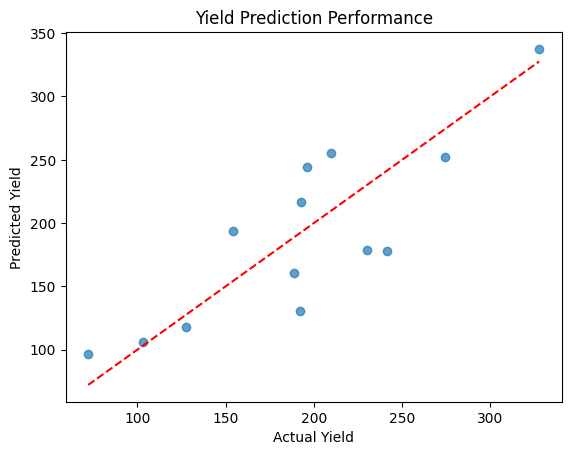

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
X = data.drop(columns=["plant_id", "yield"])
y = data["yield"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("R² score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

plt.scatter(y_test, pred, alpha=0.7)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Yield Prediction Performance")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.show()

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = data.drop(columns=["plant_id", "yield"])
y = data["yield"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

#### 4. Model Explainability with SHAP

To interpret the model, we apply SHAP to quantify the contribution of each feature to yield prediction.


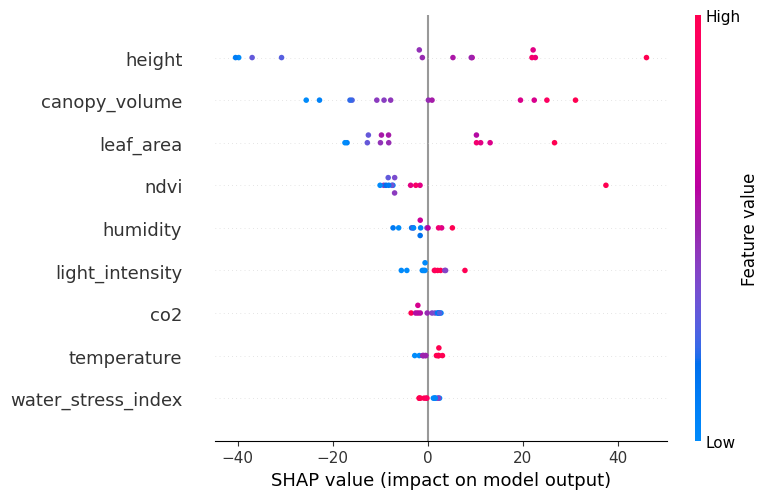

In [19]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

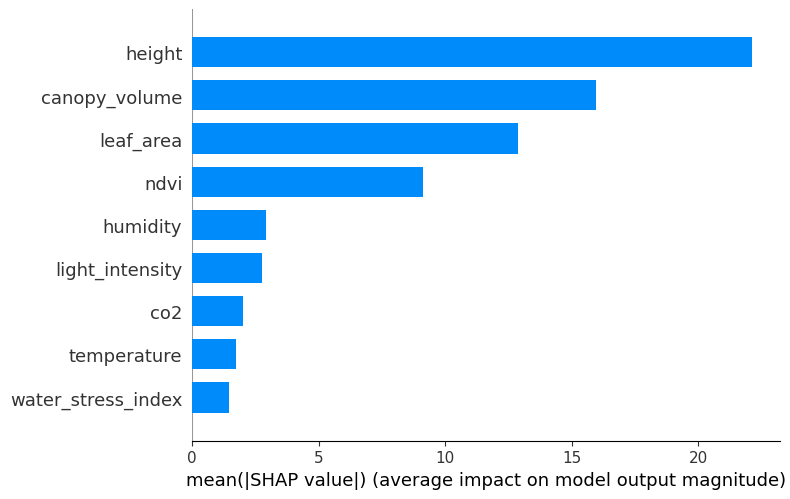

In [20]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

- **SHAP Force Plot Interpretation**

In [21]:
import shap
from IPython.display import display
shap.initjs()

#select one plant
i = 0  
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test.iloc[i]
)

The SHAP force plot explains the prediction for an individual plant by showing how each feature contributes to the final output.
The base value represents the average prediction across all samples. Features shown in red push the prediction higher, while features in blue push it lower.
In this example, structural and physiological features such as low height, canopy volume, and NDVI strongly decrease the predicted yield. Although CO₂ has a positive contribution, it is insufficient to offset the negative effects of reduced plant growth and health.
This indicates that plant structure and health are the dominant drivers of yield in the model.

#### Future Work

- Use real sensor data (LiDAR, multispectral imaging)
- Add time-series models (LSTM)
- Simulate irrigation strategies
- Extend to crop-specific modeling